In [1]:
from pathlib import Path
from typing import Tuple

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage, signal

from tqdm import tqdm
import math

# np.set_printoptions(precision=4)

ModuleNotFoundError: No module named 'cv2'

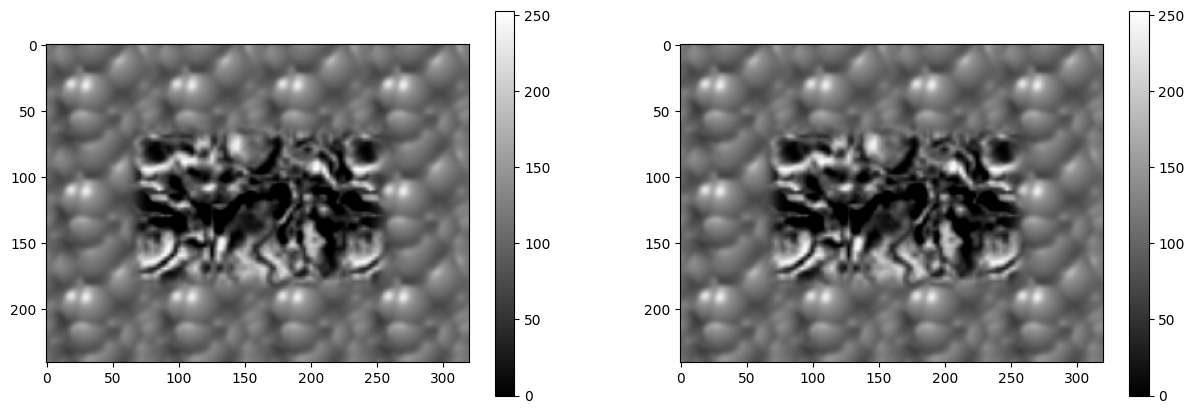

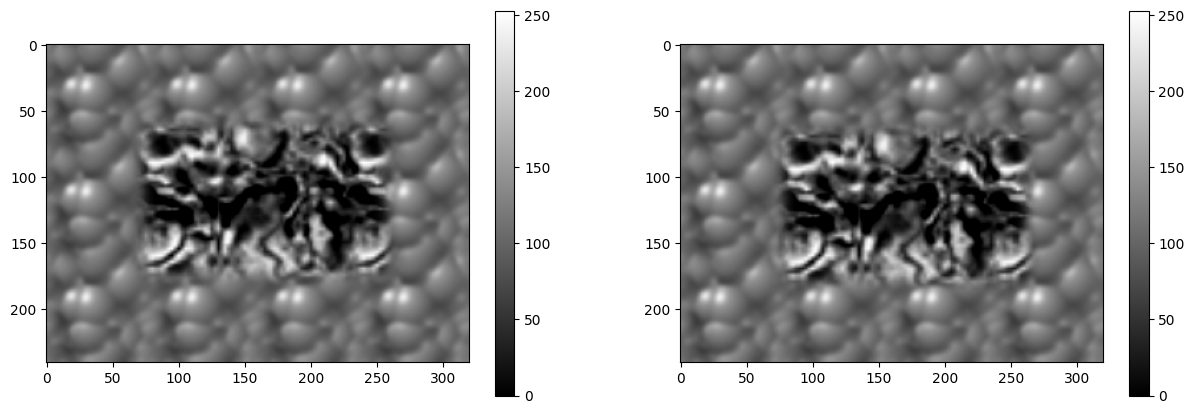

In [23]:
input_dir = Path('TestSeq')

shift_0 = cv.imread(str(input_dir / 'Shift0.png'), cv.IMREAD_GRAYSCALE).astype(np.float32) 
shift_r2 = cv.imread(str(input_dir / 'ShiftR2.png'), cv.IMREAD_GRAYSCALE).astype(np.float32) 
shift_r5u5 = cv.imread(str(input_dir / 'ShiftR5U5.png'), cv.IMREAD_GRAYSCALE).astype(np.float32)
shift_r10 = cv.imread(str(input_dir / 'ShiftR10.png'), cv.IMREAD_GRAYSCALE).astype(np.float32)
shift_r20 = cv.imread(str(input_dir / 'ShiftR20.png'), cv.IMREAD_GRAYSCALE).astype(np.float32)
shift_r40 = cv.imread(str(input_dir / 'ShiftR40.png'), cv.IMREAD_GRAYSCALE).astype(np.float32)

plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.imshow(shift_0, cmap="gray")
plt.colorbar()
plt.subplot(122)
plt.imshow(shift_r2, cmap="gray")
plt.colorbar()
plt.show()


plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.imshow(shift_r5u5, cmap="gray")
plt.colorbar()
plt.subplot(122)
plt.imshow(shift_r10, cmap="gray")
plt.colorbar()
plt.show()

In [41]:
def gradients(img, kernel_size=3, sigma=3):
    # img = img.copy().astype(np.float32)
    img = cv.GaussianBlur(img, (kernel_size, kernel_size), sigma)
    sobelx = cv.Sobel(img,cv.CV_64F,1,0,ksize=kernel_size)
    sobely = cv.Sobel(img,cv.CV_64F,0,1,ksize=kernel_size)

    # sobelx = np.uint8(np.absolute(sobelx))    
    # sobely = np.uint8(np.absolute(sobely))    
    return sobelx, sobely

def time_gradient(imgt1, imgt2):
    # return imgt2 - imgt1
    kernel_t = np.array([[1, 1, 1], [1, 1, 1], [1, 1, 1]])
    # kernel_t = np.ones((1,1),dtype=np.float32)
    return cv.filter2D(imgt2, -1, kernel_t) - cv.filter2D(imgt1, -1, kernel_t)  #Gradient over Time


def displacement_vector(Ix, Iy, It, window_size=5):
    # sum_window = lambda I: cv.filter2D(I, ddepth=-1, kernel=np.full((window_size, window_size), 100,dtype=np.float32))
    sum_window = lambda img: cv.GaussianBlur(img, (window_size, window_size), -1)
    # sum_window = lambda I: signal.convolve2d(I, np.ones((window_size, window_size),dtype=np.float32))

    summed_Ix2 = sum_window((Ix * Ix))
    summed_Iy2 = sum_window((Iy * Iy))
    summed_IxIy = sum_window((Ix * Iy))
    summed_IxIt = sum_window((Ix * It))
    summed_IyIt = sum_window((Iy * It))


    ATA = lambda i,j: np.array([[summed_Ix2[i,j], summed_IxIy[i,j]], 
                                  [summed_IxIy[i,j], summed_Iy2[i,j]]])
    ATb = lambda i,j: np.array([-1 * summed_IxIt[i,j], -1 * summed_IyIt[i,j]])

    u = np.zeros_like(Ix, dtype=np.float32)
    v = np.zeros_like(Ix, dtype=np.float32)
    # Populate the image using the function
    for i in range(u.shape[0]):
        for j in range(u.shape[1]):
            u[i,j], v[i,j] = solve(ATA(i,j), ATb(i,j))

    

    return u,v

def solve(A, b):
    return np.linalg.lstsq(A,b)[0]

def lucas_kanade(img, imgt2, k_size=21):
    [Ix, Iy], It = gradients(img, sigma=0), time_gradient(img, imgt2)
    u,v = displacement_vector(Ix, Iy, It, k_size)
    return u,v

def show_flow_field(img, u,v):
    height, width = u.shape
    y, x = np.mgrid[0:height, 0:width]

    n = 5
    x = x[::n, ::n]
    y = y[::n, ::n]
    u = u[::n, ::n]
    v = v[::n, ::n]

    # u[u < 5] == 0
    # v[v < 5] == 0

    magnitude = np.sqrt(u**2 + v**2)

    # Plot the flow fields using quiver
    plt.figure(figsize=(8,8))
    plt.imshow(img, cmap="gray")
    plt.quiver(x, y, u, v, magnitude, angles='xy', scale_units='xy', scale=0.1, headwidth=5, headlength=7, cmap='jet')
    plt.colorbar()
    # Set plot limits (optional, depending on your image dimensions)
    plt.xlim(0, width)
    plt.ylim(0, height)

    # Invert y-axis to match the image coordinate system (origin at the top-left)
    plt.gca().invert_yaxis()

    # Display the plot
    plt.show()

C:\Users\Ron Tohar\AppData\Local\Temp\ipykernel_6704\3585583340.py:46: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  return np.linalg.lstsq(A,b)[0]


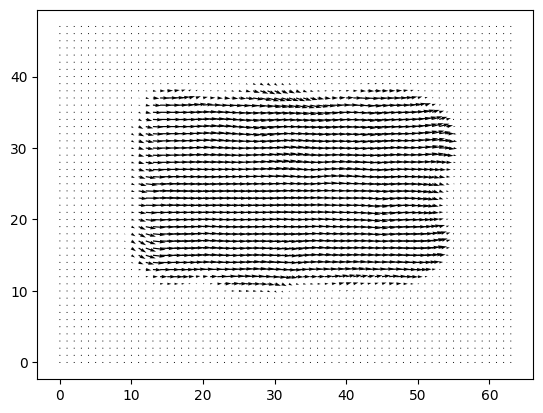

In [42]:
img = shift_0
imgt2 = shift_r2

u,v = lucas_kanade(img, imgt2, 51)
# plt.imshow(u,cmap="gray")
# plt.colorbar()
# plt.show()

scale = 5
plt.quiver(u[::scale, ::scale], v[::scale, ::scale])
# Ix,Iy = gradients(img)
# new_image = img + Ix*u +Iy*v
# plt.imshow(new_image, cmap="gray")
# plt.show()
# show_flow_field(img, Ix*u,Iy*v)


## Part 2
In lectures we described the Gaussian pyramid constructed using the REDUCE operator. Here is the original paper that defines the REDUCE and EXPAND operators:


### A

Write a function to implement REDUCE. Use this to produce a Gaussian Pyramid of 4 levels (0-3). Demonstrate using the first frame of the DataSeq1 sequence.

In [26]:
input_dir = Path('DataSeq1')

yos_1_warped = cv.imread(str(input_dir / 'yos_img_1_warped.jpg'), cv.IMREAD_GRAYSCALE).astype(np.float32) 
yos_2_warped = cv.imread(str(input_dir / 'yos_img_2_warped.jpg'), cv.IMREAD_GRAYSCALE).astype(np.float32) 
yos_1 = cv.imread(str(input_dir / 'yos_img_01.jpg'), cv.IMREAD_GRAYSCALE).astype(np.float32) 
yos_2 = cv.imread(str(input_dir / 'yos_img_02.jpg'), cv.IMREAD_GRAYSCALE).astype(np.float32) 
yos_3 = cv.imread(str(input_dir / 'yos_img_03.jpg'), cv.IMREAD_GRAYSCALE).astype(np.float32) 

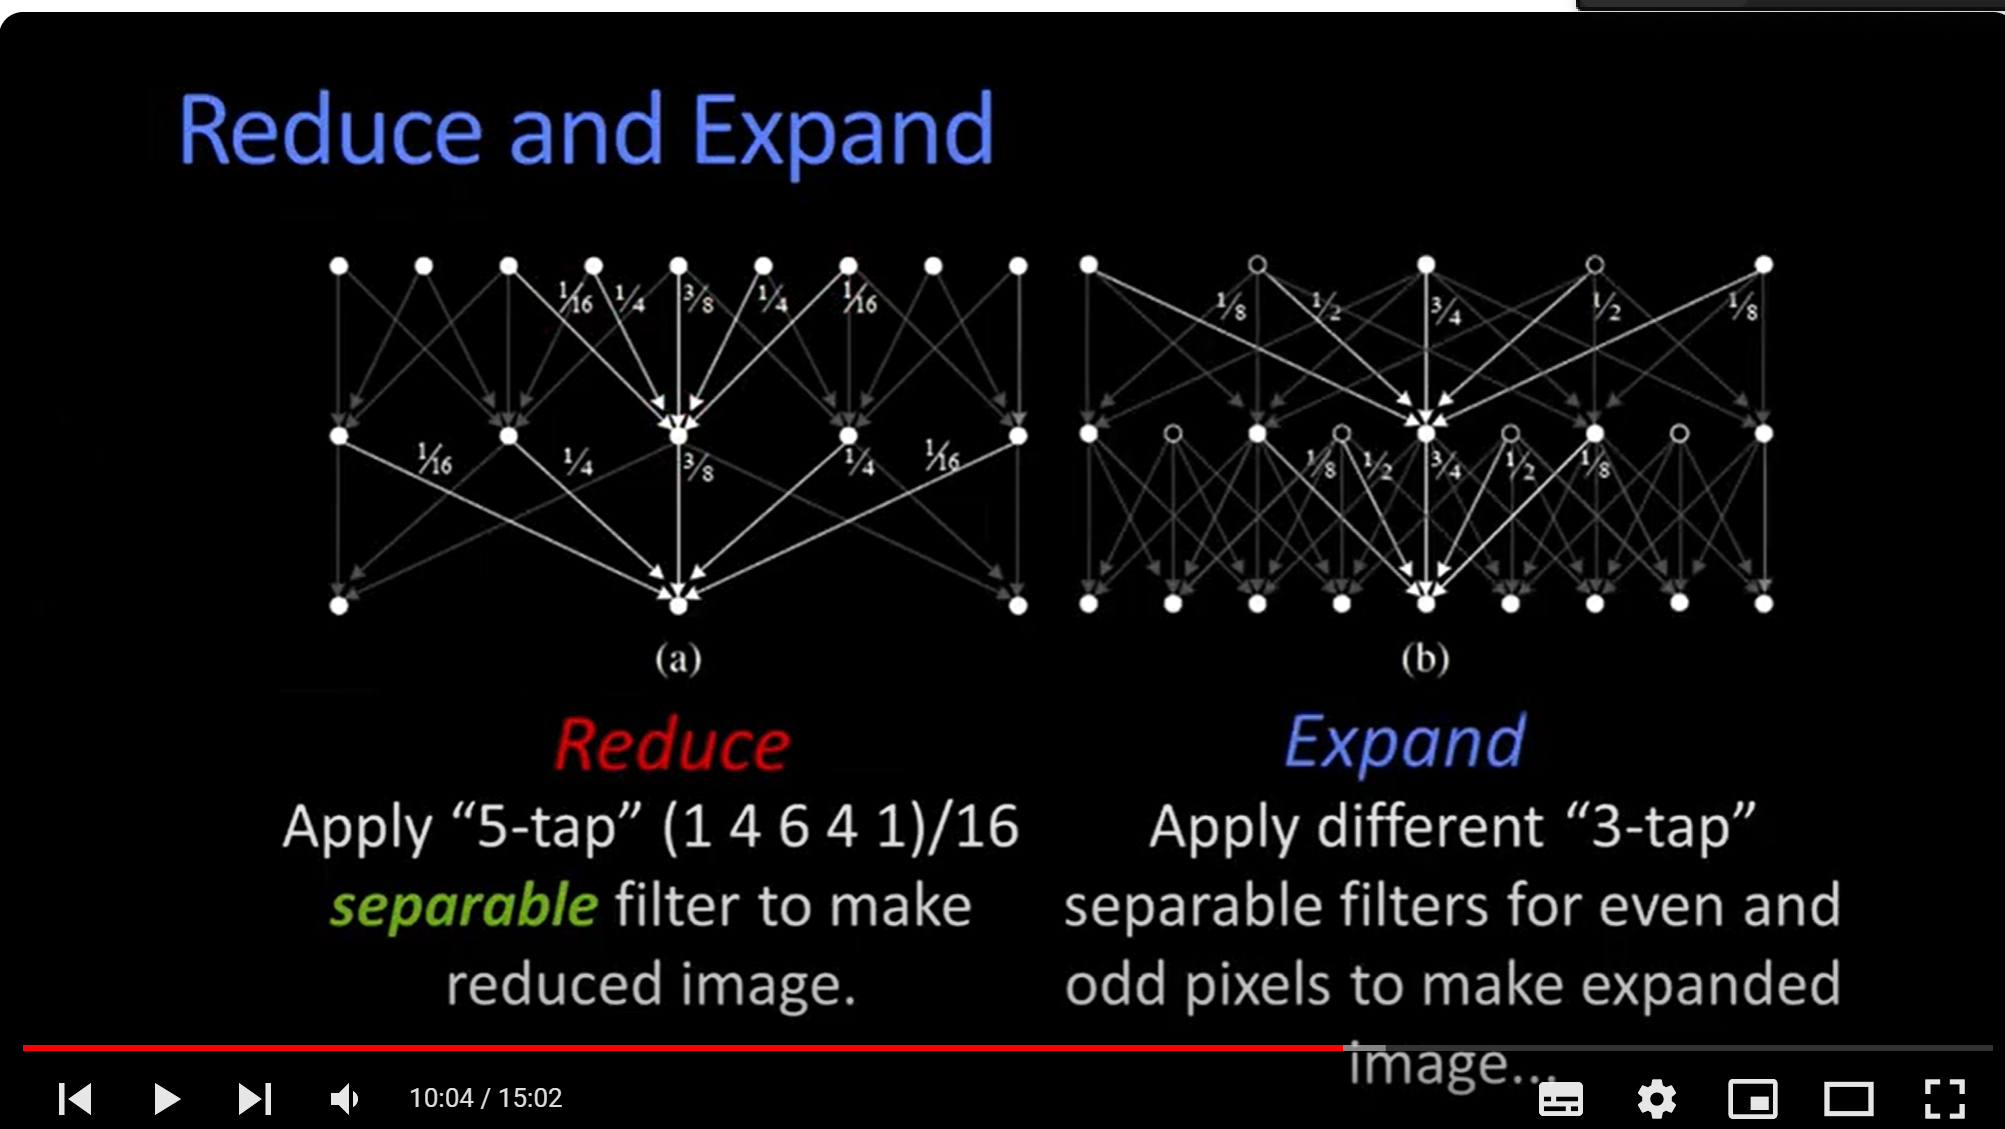

In [27]:
def REUDCE(img):
    kernel = np.array([1,4,6,4,1],dtype=np.float32)
    kernel = kernel / sum(kernel)

    # filtered_image = cv.sepFilter2D(img, ddepth=cv.CV_32F, kernelX=kernel, kernelY=np.array([1/2,1/2], dtype=np.float32))
    filtered_image = cv.sepFilter2D(img, ddepth=cv.CV_32F, kernelX=kernel, kernelY=kernel)
    return filtered_image[::2,::2]

def EXPAND(img, new_shape):
    img = img.copy().astype(np.float32)

    image_up = np.zeros((2*(img.shape[0]), 2*(img.shape[1])), dtype=np.float32)
    image_up[::2,::2] = img

    a = np.array([1,4,6,4,1]).reshape(1, -1) / 16
    a = np.dot(a.T, a)

    new_img = signal.convolve2d(image_up, a)

    if new_shape[1] < new_img.shape[1]:
        new_img = new_img[:,:-1]

    if new_shape[0] < new_img.shape[0]:
        new_img = new_img[:-1,:]
    # return np.array(new_img)
    return cv.resize(img, new_shape[::-1])

# Returns gaussians reduced
def gaussian_pyramid(img, levels=4):
    gaussians = [img]
    for _ in range(levels-1):
        gaussians.append(REUDCE(gaussians[-1]))

    return gaussians      

def difference_of_gaussians(gaussians):
    expanded = [EXPAND(gaussians[i+1], gaussians[i].shape) for i in range(len(gaussians)-1)]
    subtracted = [gaussians[i] - expanded[i] for i in range(len(expanded))]
    return subtracted

# Returns all laplacians and the most coarse gaussian
# number of levels includes the original img
def laplacian_pyramid(img, levels=4):
    gaussians = gaussian_pyramid(img, levels)
    # print([g.shape for g in gaussians] )
    laplacians = difference_of_gaussians(gaussians)
    laplacians.append(gaussians[-1])
    return laplacians



got 4 laplacians


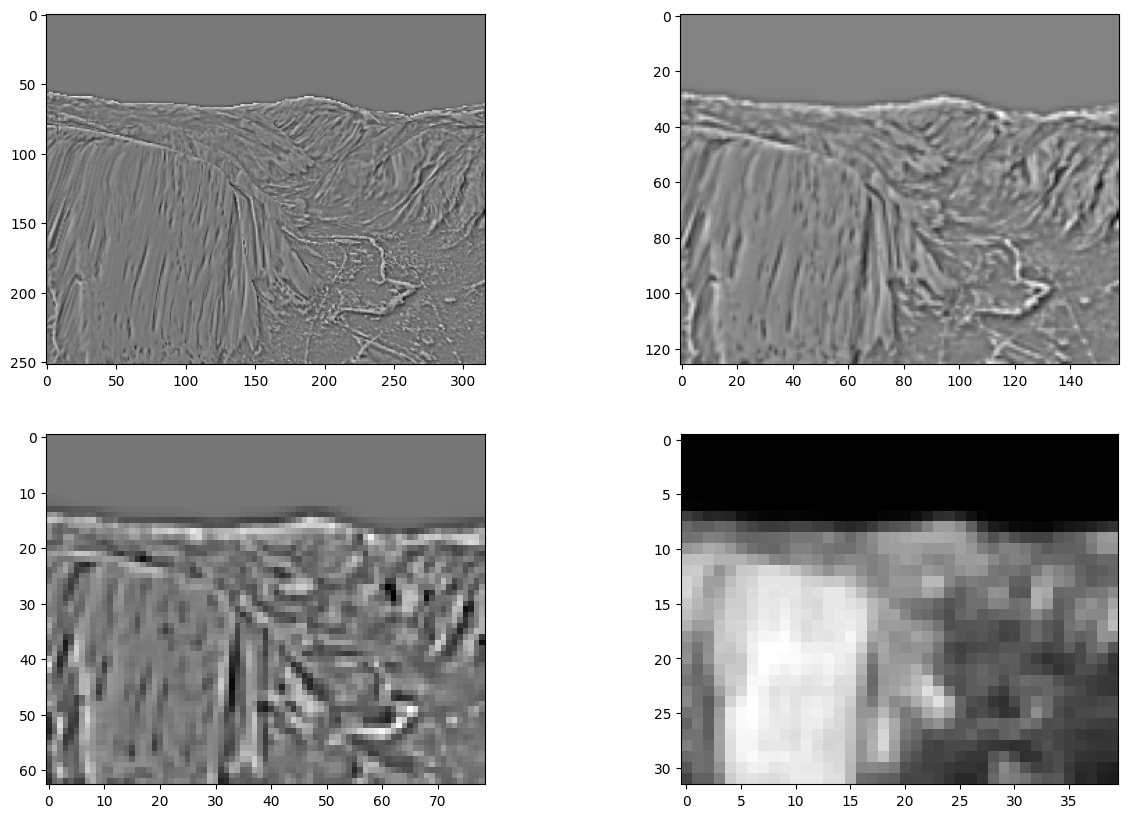

In [28]:
laplacians = laplacian_pyramid(yos_1, levels=4)
# laplacians = gaussian_pyramid(yos_1, levels=5)
print(f"got {len(laplacians)} laplacians")
plt.figure(figsize=(15,10))
plt.subplot(221)
plt.imshow(laplacians[0], cmap="gray")
plt.subplot(222)
plt.imshow(laplacians[1], cmap="gray")
plt.subplot(223)
plt.imshow(laplacians[2], cmap="gray")
plt.subplot(224)
plt.imshow(laplacians[3], cmap="gray")

plt.show()

In [8]:
def euclidean_to_homogenous(euclidean_pts):
    return np.hstack((euclidean_pts, np.ones((len(euclidean_pts), 1))))

def homogenous_to_euclidean(homogenous_pts):
    return np.array([pt[:-1] / pt[-1] for pt in homogenous_pts])

def get_point_value(original_img, warped_x, warped_y):
    f = lambda x,y: original_img[y,x] if 0<=x<original_img.shape[1] and 0<=y<original_img.shape[0] else 0
    i = math.floor(warped_x) # represents x-like coordinate
    j = math.floor(warped_y) # represents y-like coordinate

    a = warped_x - i
    b = warped_y - j
    
    value = (1-a)*(1-b)*f(i,j) + a*(1-b)*f(i+1,j) + a*b*f(i+1,j+1) +(1-a)*b*f(i,j+1)
    return value


def warp(img1, matrix_img1_to_img2):
    matrix_img2_to_img1 = np.linalg.inv(matrix_img1_to_img2)

    points_img2 = np.array([[x,y] for x in range(img1.shape[1]) for y in range(img1.shape[0])]) 
    homogenous_inverse_warped = [matrix_img2_to_img1 @ point for point in euclidean_to_homogenous(points_img2)]
    inverse_warped_indices = homogenous_to_euclidean(homogenous_inverse_warped)
    inverse_warped_indices = inverse_warped_indices.reshape((img1.shape[1],img1.shape[0],2))

    new_img = np.zeros_like(img1)

    for y in range(new_img.shape[0]):
        for x in range(new_img.shape[1]):
            new_img[y,x] = get_point_value(img1, *inverse_warped_indices[x,y])

    return new_img

In [31]:
def warp_with_flow(I2, vx, vy):
    M,N = I2.shape
    y,x = np.meshgrid(np.arange(M),np.arange(N), indexing="ij")
    map_x = (x + vx).reshape(M,N).astype(np.float32)
    map_y = (y + vy).reshape(M,N).astype(np.float32)
    warped_img = cv.remap(I2, map_x, map_y, interpolation=cv.INTER_LINEAR, borderMode=cv.BORDER_REPLICATE)
    return warped_img





In [61]:
def iterative_LK(L, R, n=5, k_size=31):
    left_laplacian_pyramid = laplacian_pyramid(L, n+1)
    right_laplacian_pyramid = laplacian_pyramid(R, n+1)

    u = np.zeros_like(left_laplacian_pyramid[n])
    v = np.zeros_like(left_laplacian_pyramid[n])

    for k in tqdm(range(n-1,-1,-1)):
        lk = left_laplacian_pyramid[k]
        rk = right_laplacian_pyramid[k]

        u = 2* EXPAND(u, lk.shape)
        v = 2* EXPAND(v, lk.shape)

        wk = warp_with_flow(lk, u, v)
        dx, dy = lucas_kanade(wk, rk, k_size=k_size)
        u = u + dx
        v = v + dy
        k_size *= 2 + 1
        # show_flow_field(L,u,v)


    return u,v

def warp_with_hierarchical_lk(img1, img2):
    u,v = iterative_LK(img1, img2, n=5)
    warped_img = warp_with_flow(img1, u, v)
    return warped_img

def get_real_flow(frame1, frame2):
    from scipy.interpolate import griddata
    # Step 1: Detect feature points in frame1 using Shi-Tomasi corner detection
    feature_params = dict(maxCorners=100, qualityLevel=0.3, minDistance=7, blockSize=7)
    p0 = cv.goodFeaturesToTrack(frame1, mask=None, **feature_params)

    # Step 2: Calculate optical flow for the feature points using the Lucas-Kanade method
    lk_params = dict(winSize=(15, 15), maxLevel=2,
                    criteria=(cv.TERM_CRITERIA_EPS | cv.TERM_CRITERIA_COUNT, 10, 0.03))

    p1, st, err = cv.calcOpticalFlowPyrLK(frame1, frame2, p0, None, **lk_params)

    # Filter good points
    good_new = p1[st == 1]
    good_old = p0[st == 1]

    # Step 3: Interpolate sparse flow to a dense flow field
    h, w = frame1.shape
    x, y = np.meshgrid(np.arange(w), np.arange(h))

    # Get sparse displacements
    dx = good_new[:, 0] - good_old[:, 0]
    dy = good_new[:, 1] - good_old[:, 1]

    # Interpolate to get dense flow fields
    u = griddata(good_old, dx, (x, y), method='cubic', fill_value=0)
    v = griddata(good_old, dy, (x, y), method='cubic', fill_value=0)
    return u,v


def hierarchical_lk(img1, img2, n=5):

    u,v = iterative_LK(img1, img2, n,7)
    # u,v = lucas_kanade(img1, img2, 31)
    # u,v = get_real_flow(img1.astype(np.uint8),img2.astype(np.uint8))
    warped = warp_with_flow(img1,u,v)
    

    print("real img size", img1.shape)
    plt.figure(figsize=(15, 10))
    plt.subplot(221)
    plt.title("image t0")
    plt.imshow(img1, cmap="gray")
    plt.subplot(222)
    plt.title("image t1")
    plt.imshow(img2, cmap="gray")
    plt.subplot(223)
    plt.title("t0 warped")
    plt.imshow(warped, cmap="gray")
    plt.tight_layout()
    plt.show()  
    show_flow_field(img1, u,v)

  0%|          | 0/4 [00:00<?, ?it/s]

C:\Users\Ron Tohar\AppData\Local\Temp\ipykernel_6704\3585583340.py:46: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  return np.linalg.lstsq(A,b)[0]
100%|██████████| 4/4 [00:03<00:00,  1.06it/s]


real img size (240, 320)


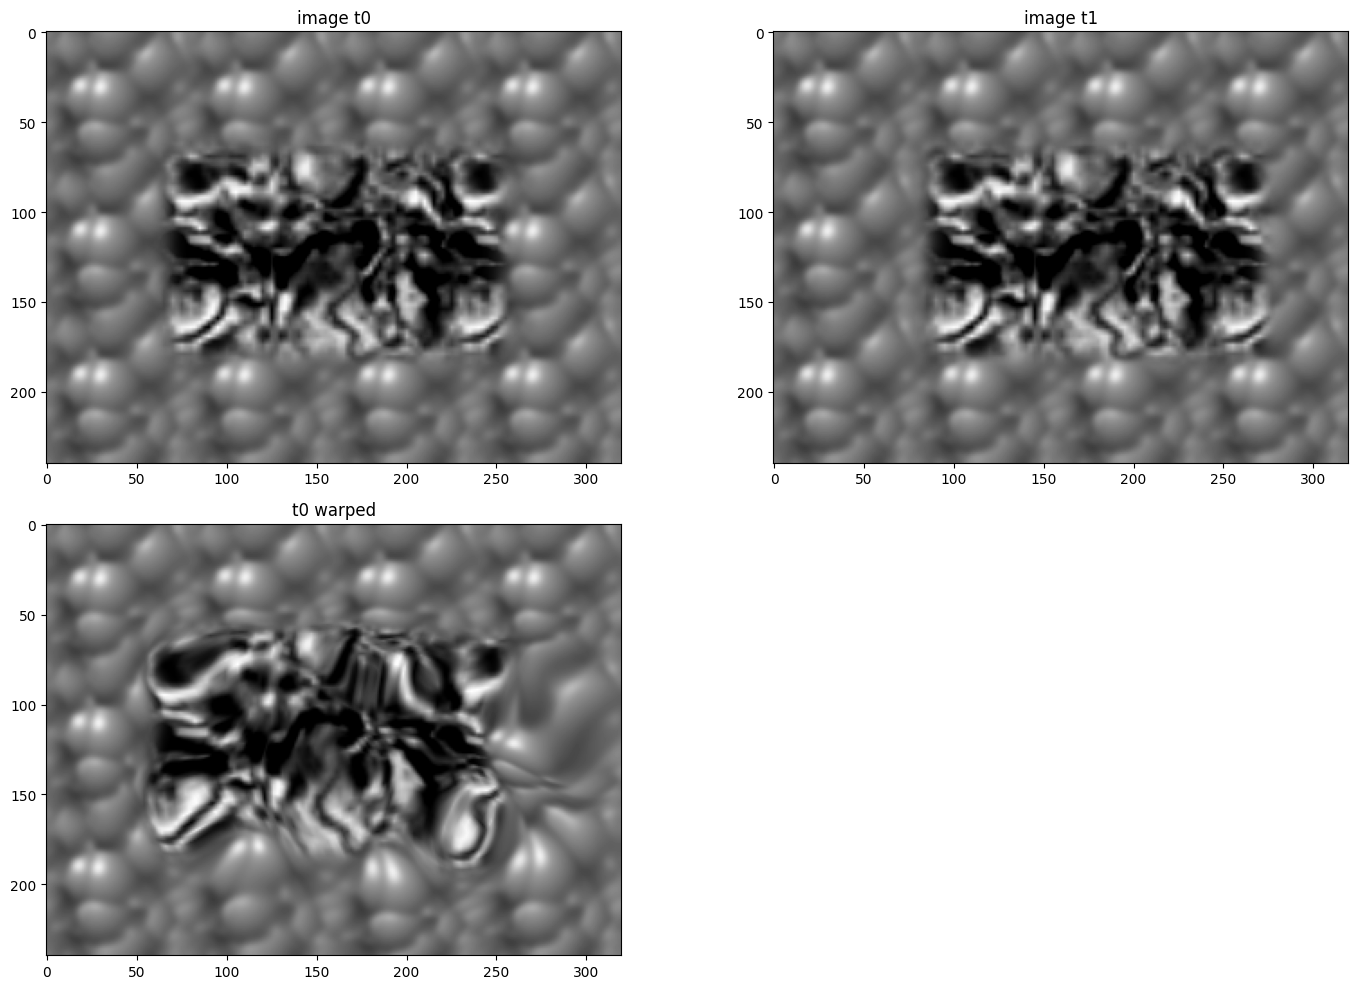

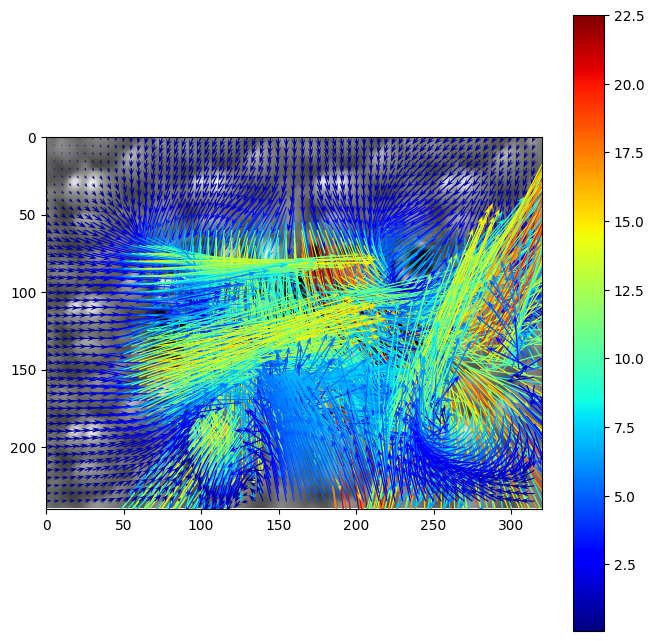

100%|██████████| 4/4 [00:04<00:00,  1.06s/it]


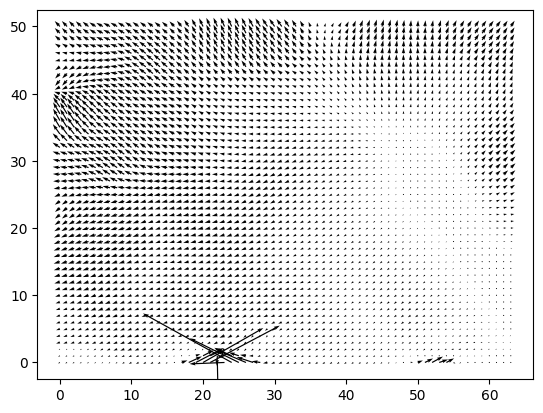

In [64]:
hierarchical_lk(shift_0, shift_r20, 4)
u,v = iterative_LK(yos_1, yos_1_warped, 4, k_size=7)
scale = 5
plt.quiver(u[::scale, ::scale], v[::scale, ::scale])


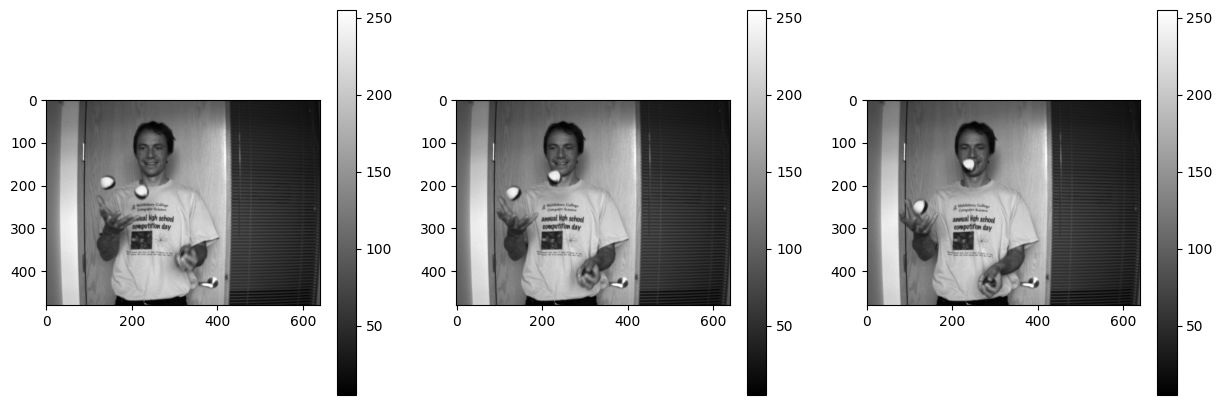

In [62]:
input_dir = Path('Juggle')

juggle0 = cv.imread(str(input_dir / '0.png'), cv.IMREAD_GRAYSCALE).astype(np.float32) 
juggle1= cv.imread(str(input_dir / '1.png'), cv.IMREAD_GRAYSCALE).astype(np.float32) 
juggle2 = cv.imread(str(input_dir / '2.png'), cv.IMREAD_GRAYSCALE).astype(np.float32)

plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(juggle0, cmap="gray")
plt.colorbar()
plt.subplot(132)
plt.imshow(juggle1, cmap="gray")
plt.colorbar()
plt.subplot(133)
plt.imshow(juggle2, cmap="gray")
plt.colorbar()
plt.show()

  0%|          | 0/4 [00:00<?, ?it/s]C:\Users\Ron Tohar\AppData\Local\Temp\ipykernel_6704\3585583340.py:46: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  return np.linalg.lstsq(A,b)[0]
100%|██████████| 4/4 [00:13<00:00,  3.33s/it]


real img size (480, 640)


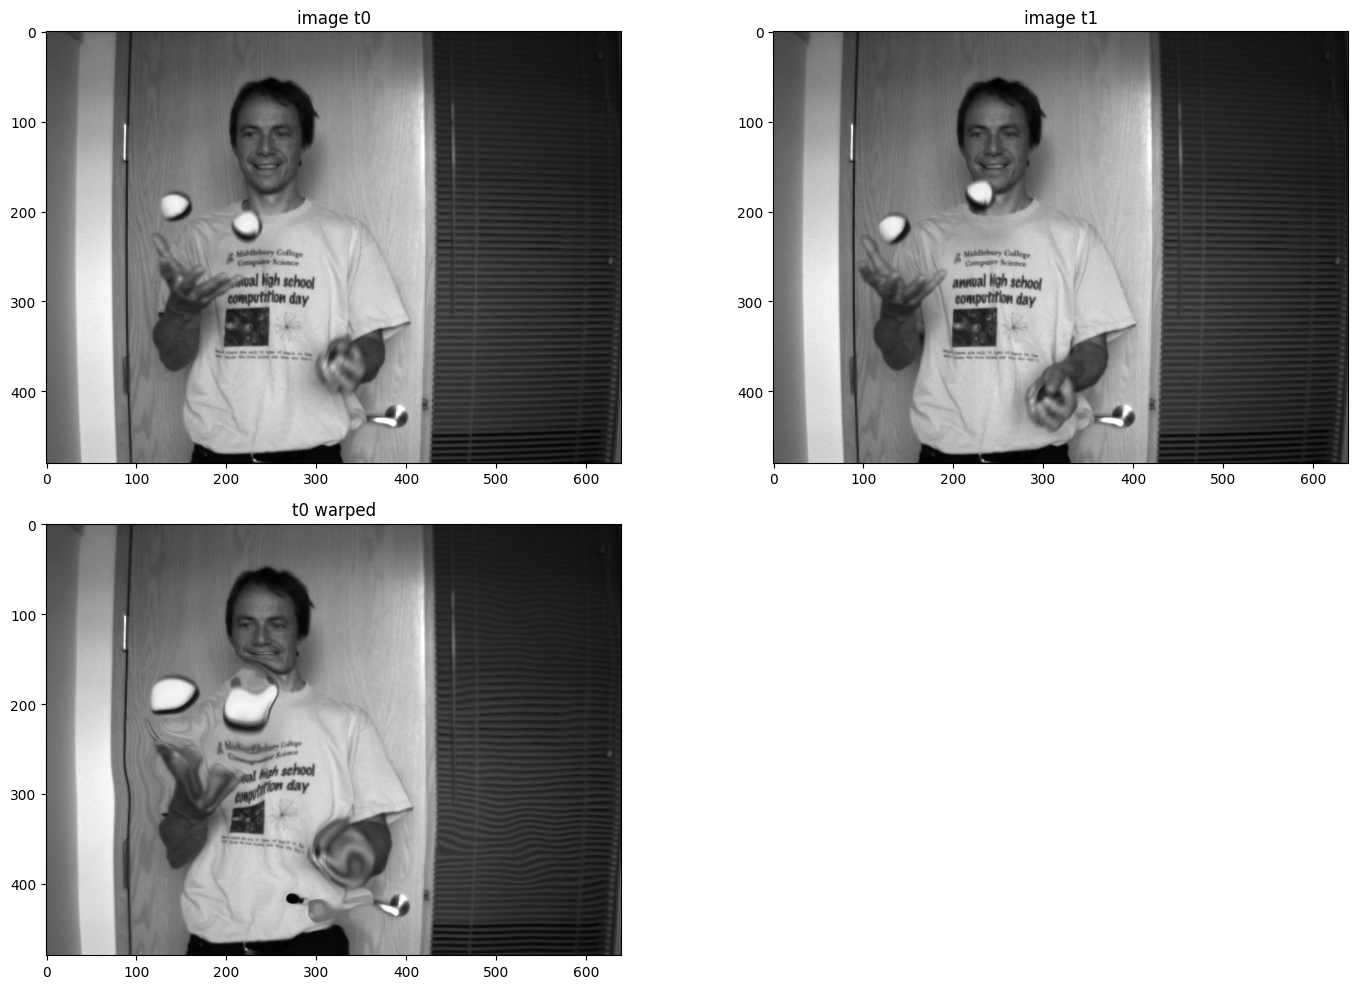

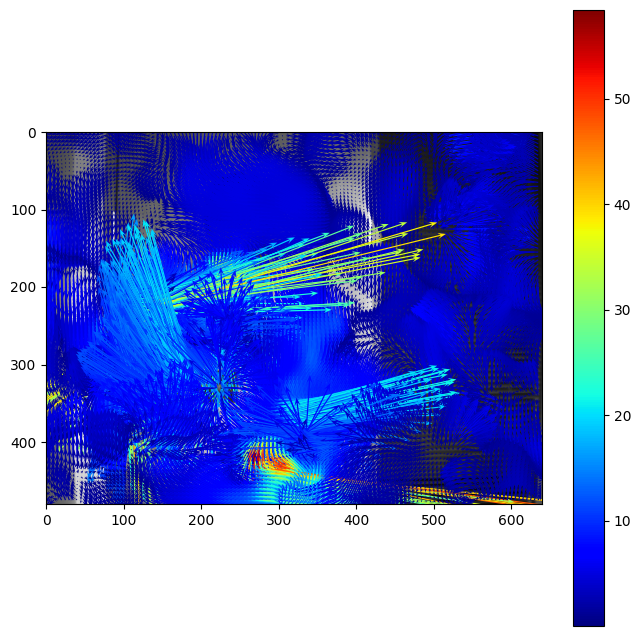

In [63]:
hierarchical_lk(juggle0,juggle1,4)